# Artificial Neural Network (ANN) – XOR Problem

An Artificial Neural Network (ANN) is a computational model inspired by the human brain.

This implementation solves the **XOR classification problem** using a simple feedforward neural network with:

- Input layer (2 neurons)
- Hidden layer (2 neurons)
- Output layer (1 neuron)

The network is trained using **backpropagation** and **gradient descent**.

---

## Activation Function

The sigmoid activation function is used:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

---

## Neuron Output

The output of a neuron is:

$$
y = \sigma(w \cdot x + b)
$$

Where:

- \(w\) = weights  
- \(x\) = input vector  
- \(b\) = bias  
- \(\sigma\) = activation function  

---

## Loss Function

Mean Squared Error (MSE) is used:

$$
L = \frac{1}{n}\sum (y - \hat{y})^2
$$

Where:

- \(y\) = actual output  
- \(\hat{y}\) = predicted output  

---

## Training Process

The network is trained using **forward propagation** and **backpropagation**.

Weights are updated using gradient descent:

$$
w = w + \eta \cdot \Delta w
$$

Where:

- \(\eta \) = learning rate
- \(\Delta w \) = weight update

Final Predictions:
[[0.11 ]
 [0.447]
 [0.907]
 [0.457]]


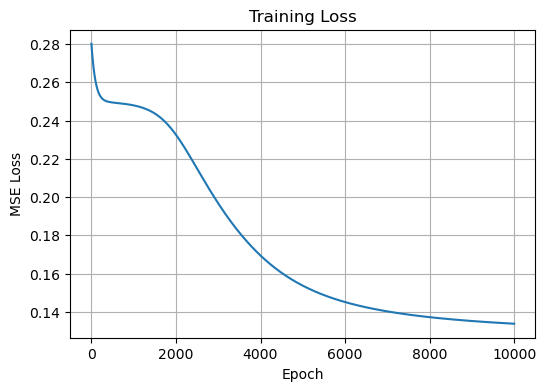

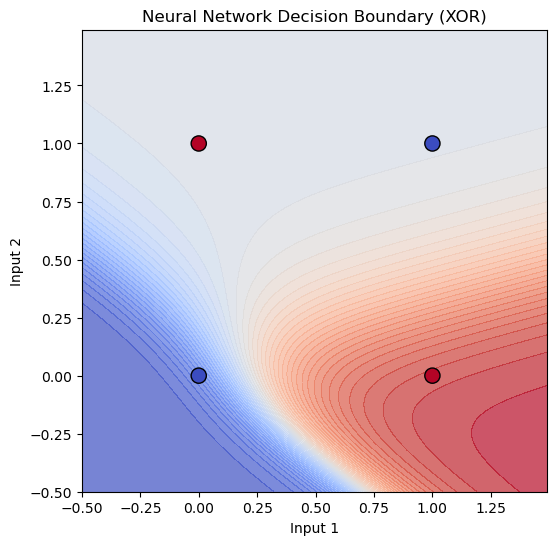

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input dataset (XOR)
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Output labels
y = np.array([[0],[1],[1],[0]])

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# Set random seed
np.random.seed(1)

# Initialize weights
weights_input_hidden = np.random.uniform(-1,1,(2,2))
weights_hidden_output = np.random.uniform(-1,1,(2,1))

# Initialize biases
bias_hidden = np.random.uniform(-1,1,(1,2))
bias_output = np.random.uniform(-1,1,(1,1))

learning_rate = 0.1
epochs = 10000

loss_history = []

# Training loop
for epoch in range(epochs):

    # Forward propagation
    hidden_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, weights_hidden_output) + bias_output
    predicted_output = sigmoid(final_input)

    # Error calculation
    error = y - predicted_output
    loss = np.mean(np.square(error))
    loss_history.append(loss)

    # Backpropagation
    d_predicted = error * sigmoid_derivative(predicted_output)

    error_hidden = d_predicted.dot(weights_hidden_output.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # Weight updates
    weights_hidden_output += hidden_output.T.dot(d_predicted) * learning_rate
    weights_input_hidden += X.T.dot(d_hidden) * learning_rate

# Final predictions
print("Final Predictions:")
print(np.round(predicted_output,3))


# Plot training loss
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# Decision boundary visualization
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Forward pass for grid
hidden = sigmoid(np.dot(grid, weights_input_hidden) + bias_hidden)
output = sigmoid(np.dot(hidden, weights_hidden_output) + bias_output)

Z = output.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.7)

# Plot training points
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap="coolwarm", s=120, edgecolors='k')

plt.title("Neural Network Decision Boundary (XOR)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()

# Algorithm: Artificial Neural Network for XOR

### Step 1: Start

Begin neural network training.

---

### Step 2: Input Dataset

Input dataset:

X = {(0,0), (0,1), (1,0), (1,1)}

Output labels:

Y = {0,1,1,0}

---

### Step 3: Initialize Parameters

Initialize weights and biases randomly.

Set learning rate and number of epochs.

---

### Step 4: Forward Propagation

Compute hidden layer output:

Hidden = sigmoid(XW₁ + b₁)

Compute final output:

Output = sigmoid(Hidden W₂ + b₂)

---

### Step 5: Compute Error

Calculate error between predicted output and actual output.

Compute loss using Mean Squared Error.

---

### Step 6: Backpropagation

Compute gradients using derivative of sigmoid function.

Update weights and biases using gradient descent.

---

### Step 7: Repeat

Repeat forward propagation and backpropagation for all epochs.

---

### Step 8: Output

Final trained neural network and predicted outputs.

---

### Step 9: End